In [3]:
"""
Analyze planning time from timestamp CSV files across different planners.

This script:
1. Scans trial directories for timestamp CSV files
2. Extracts planner type and settings from folder names and run.log
3. Computes average planning time per step per agent
4. Generates comparison statistics

Usage:
    python analyze_planning_time.py
    python analyze_planning_time.py --trials-dir trials --output results.csv
"""

import os
import glob
import re
import argparse
import numpy as np
import pandas as pd
from pathlib import Path
from typing import Dict, List, Tuple, Optional
from collections import defaultdict


def parse_folder_name(folder_name: str) -> Dict[str, str]:
    """
    Extract planner info from folder name.
    
    Examples:
        greedy_ig_gaussian_r4_corner_N4_IG_BS_commR5
        dec_mcts_gaussian_r4_corner_N4_IGd_BM_comm15.625
        mh_dec_mcts_gaussian_r4_corner_N4_IG_BS_comm15.625
        mh_dec_mcts_both_gaussian_r4_corner_N4_IGd_BM_comm15.625
    
    Returns:
        Dict with keys: planner, variant, radius, num_agents, news_mode, comm_range
    """
    info = {}
    
    # Planner type
    if folder_name.startswith("greedy_ig"):
        info["planner"] = "Greedy-IG"
    elif folder_name.startswith("mh_dec_mcts_both"):
        info["planner"] = "MH-Dec-MCTS-Both"
    elif folder_name.startswith("mh_dec_mcts"):
        info["planner"] = "MH-Dec-MCTS"
    elif folder_name.startswith("dec_mcts"):
        info["planner"] = "Dec-MCTS"
    else:
        info["planner"] = "Unknown"
    
    # Variant (IG vs IGd)
    if "_IGd_" in folder_name:
        info["variant"] = "IGd"
    elif "_IG_" in folder_name:
        info["variant"] = "IG"
    else:
        info["variant"] = "Unknown"
    
    # Radius
    radius_match = re.search(r"_r(\d+)", folder_name)
    info["radius"] = radius_match.group(1) if radius_match else "Unknown"
    
    # Number of agents
    n_match = re.search(r"_N(\d+)", folder_name)
    info["num_agents"] = int(n_match.group(1)) if n_match else 0
    
    # News mode (IG_BS, IG_BM, IGd_BM, etc.)
    news_match = re.search(r"_(IG[d]?_[A-Z]{2})", folder_name)
    info["news_mode"] = news_match.group(1) if news_match else "Unknown"
    
    # Communication range
    comm_match = re.search(r"_comm([R\d.]+)", folder_name)
    info["comm_range"] = comm_match.group(1) if comm_match else "Unknown"
    
    return info


def parse_run_log(log_path: str) -> Dict[str, str]:
    """
    Parse run.log to extract additional metadata.
    
    Returns:
        Dict with strategy, pairwise mode, news mode, etc.
    """
    metadata = {}
    
    if not os.path.exists(log_path):
        return metadata
    
    with open(log_path, "r") as f:
        for line in f:
            line = line.strip()
            if line.startswith("Strategy:"):
                metadata["strategy"] = line.split(":")[1].strip()
            elif line.startswith("Pairwise:"):
                metadata["pairwise"] = line.split(":")[1].strip()
            elif line.startswith("News mode:"):
                metadata["news_mode"] = line.split(":")[1].strip()
            elif line.startswith("Num agents:"):
                try:
                    metadata["num_agents"] = int(line.split(":")[1].strip())
                except:
                    pass
            elif line.startswith("Gaussian radius"):
                try:
                    metadata["radius"] = line.split("radius")[1].strip()
                except:
                    pass
    
    return metadata


def load_timestamps(csv_path: str) -> pd.DataFrame:
    """
    Load timestamp CSV and compute planning time per step per agent.
    
    Returns:
        DataFrame with columns: step, agent_id, planning_time_ms
    """
    df = pd.read_csv(csv_path)
    
    # Compute planning time (end - start)
    df["planning_time_ms"] = df["end_ms"] - df["start_ms"]
    
    return df[["step", "agent_id", "planning_time_ms"]]


def analyze_trial(trial_dir: str) -> Optional[Dict]:
    """
    Analyze a single trial directory.
    
    Returns:
        Dict with trial metadata and timing statistics, or None if no timestamps found
    """
    trial_path = Path(trial_dir)
    folder_name = trial_path.name
    
    # Parse folder name
    info = parse_folder_name(folder_name)
    
    # Parse run.log
    run_log_path = trial_path / "txt" / "run.log"
    log_metadata = parse_run_log(str(run_log_path))
    info.update(log_metadata)
    
    # Check for timestamp files
    txt_dir = trial_path / "txt"
    if not txt_dir.exists():
        return None
    
    timestamps_csv = txt_dir / "timestamps.csv"
    timestamps_hlp_csv = txt_dir / "timestamps_hlp.csv"
    timestamps_llp_csv = txt_dir / "timestamps_llp.csv"
    
    result = {
        "trial_dir": str(trial_dir),
        "folder_name": folder_name,
        **info,
    }
    
    # Load main timestamps (all planners have this)
    if timestamps_csv.exists():
        df = load_timestamps(str(timestamps_csv))
        
        # Compute statistics
        result["total_steps"] = df["step"].max() + 1
        result["total_agents"] = df["agent_id"].nunique()
        result["total_plans"] = len(df)
        
        # Per-step per-agent statistics
        result["mean_time_ms"] = df["planning_time_ms"].mean()
        result["median_time_ms"] = df["planning_time_ms"].median()
        result["std_time_ms"] = df["planning_time_ms"].std()
        result["min_time_ms"] = df["planning_time_ms"].min()
        result["max_time_ms"] = df["planning_time_ms"].max()
        
        # Per-agent averages
        agent_stats = df.groupby("agent_id")["planning_time_ms"].agg(["mean", "std"])
        for agent_id, row in agent_stats.iterrows():
            result[f"agent_{agent_id}_mean_ms"] = row["mean"]
            result[f"agent_{agent_id}_std_ms"] = row["std"]
    
    # Load HLP timestamps (MH planners only)
    if timestamps_hlp_csv.exists():
        df_hlp = load_timestamps(str(timestamps_hlp_csv))
        result["hlp_mean_time_ms"] = df_hlp["planning_time_ms"].mean()
        result["hlp_median_time_ms"] = df_hlp["planning_time_ms"].median()
        result["hlp_std_time_ms"] = df_hlp["planning_time_ms"].std()
        result["hlp_min_time_ms"] = df_hlp["planning_time_ms"].min()
        result["hlp_max_time_ms"] = df_hlp["planning_time_ms"].max()
    
    # Load LLP timestamps (MH planners only)
    if timestamps_llp_csv.exists():
        df_llp = load_timestamps(str(timestamps_llp_csv))
        result["llp_mean_time_ms"] = df_llp["planning_time_ms"].mean()
        result["llp_median_time_ms"] = df_llp["planning_time_ms"].median()
        result["llp_std_time_ms"] = df_llp["planning_time_ms"].std()
        result["llp_min_time_ms"] = df_llp["planning_time_ms"].min()
        result["llp_max_time_ms"] = df_llp["planning_time_ms"].max()
    
    return result


def analyze_all_trials(trials_dir: str = "trials") -> pd.DataFrame:
    """
    Analyze all trial directories and return summary DataFrame.
    """
    results = []
    
    # Find all trial directories
    trials_path = Path(trials_dir)
    if not trials_path.exists():
        print(f"Error: Trials directory not found: {trials_dir}")
        return pd.DataFrame()
    
    trial_dirs = [d for d in trials_path.iterdir() if d.is_dir()]
    
    print(f"Found {len(trial_dirs)} trial directories")
    
    for trial_dir in sorted(trial_dirs):
        print(f"Analyzing: {trial_dir.name}")
        result = analyze_trial(str(trial_dir))
        if result:
            results.append(result)
        else:
            print(f"  -> No timestamp data found")
    
    if not results:
        print("No trials with timestamp data found!")
        return pd.DataFrame()
    
    df = pd.DataFrame(results)
    return df


def print_summary(df: pd.DataFrame):
    """Print summary statistics grouped by planner type."""
    if df.empty:
        print("No data to summarize")
        return
    
    print("\n" + "="*80)
    print("PLANNING TIME ANALYSIS SUMMARY")
    print("="*80)
    
    # Group by planner type
    if "planner" in df.columns:
        print("\nAverage Planning Time by Planner Type:")
        print("-" * 80)
        
        grouped = df.groupby("planner").agg({
            "mean_time_ms": ["mean", "std", "min", "max"],
            "total_plans": "sum",
            "folder_name": "count"
        })
        
        for planner in grouped.index:
            planner_df = df[df["planner"] == planner]
            print(f"\n{planner}:")
            print(f"  Trials: {len(planner_df)}")
            print(f"  Mean time: {planner_df['mean_time_ms'].mean():.2f} ± {planner_df['mean_time_ms'].std():.2f} ms")
            print(f"  Median time: {planner_df['median_time_ms'].mean():.2f} ms")
            print(f"  Range: [{planner_df['min_time_ms'].min():.2f}, {planner_df['max_time_ms'].max():.2f}] ms")
            
            # HLP/LLP breakdown for MH planners
            if "hlp_mean_time_ms" in planner_df.columns and planner_df["hlp_mean_time_ms"].notna().any():
                print(f"  HLP mean: {planner_df['hlp_mean_time_ms'].mean():.2f} ± {planner_df['hlp_std_time_ms'].mean():.2f} ms")
                print(f"  LLP mean: {planner_df['llp_mean_time_ms'].mean():.2f} ± {planner_df['llp_std_time_ms'].mean():.2f} ms")
    
    # Group by variant (IG vs IGd)
    if "variant" in df.columns:
        print("\n" + "-" * 80)
        print("Average Planning Time by Variant (IG vs IGd):")
        print("-" * 80)
        
        for variant in sorted(df["variant"].unique()):
            variant_df = df[df["variant"] == variant]
            print(f"\n{variant}:")
            print(f"  Trials: {len(variant_df)}")
            print(f"  Mean time: {variant_df['mean_time_ms'].mean():.2f} ± {variant_df['mean_time_ms'].std():.2f} ms")
    
    print("\n" + "="*80)


def main():
    parser = argparse.ArgumentParser(
        description="Analyze planning time from timestamp CSV files"
    )
    parser.add_argument(
        "--trials-dir",
        type=str,
        default="trials",
        help="Directory containing trial folders (default: trials)",
    )
    parser.add_argument(
        "--output",
        type=str,
        help="Output CSV file for detailed results (optional)",
    )
    parser.add_argument(
        "--summary-only",
        action="store_true",
        help="Only print summary, don't show full table",
    )
    
    args = parser.parse_args()
    
    # Analyze all trials
    df = analyze_all_trials(args.trials_dir)
    
    if df.empty:
        print("No data to analyze!")
        return
    
    # Print summary
    print_summary(df)
    
    # Show full table
    if not args.summary_only:
        print("\n" + "="*80)
        print("DETAILED RESULTS")
        print("="*80)
        
        # Select key columns for display
        display_cols = [
            "planner", "variant", "num_agents", "news_mode",
            "mean_time_ms", "median_time_ms", "std_time_ms",
            "total_steps", "total_plans"
        ]
        
        # Add HLP/LLP if available
        if "hlp_mean_time_ms" in df.columns:
            display_cols.extend(["hlp_mean_time_ms", "llp_mean_time_ms"])
        
        # Filter to available columns
        display_cols = [c for c in display_cols if c in df.columns]
        
        print(df[display_cols].to_string(index=False))
    
    # Save to file if requested
    if args.output:
        df.to_csv(args.output, index=False)
        print(f"\nDetailed results saved to: {args.output}")


if __name__ == "__main__":
    main()

usage: ipykernel_launcher.py [-h] [--trials-dir TRIALS_DIR] [--output OUTPUT]
                             [--summary-only]
ipykernel_launcher.py: error: unrecognized arguments: --f=/run/user/1000/jupyter/runtime/kernel-v3cea22d944cfcfb2fd680641893f8dfd86f80abc9.json


SystemExit: 2

In [4]:
"""
Analyze planning time from timestamp CSV files across different planners.

This script:
1. Scans trial directories for timestamp CSV files
2. Extracts planner type and settings from folder names and run.log
3. Computes average planning time per step per agent
4. Generates comparison statistics

Usage in Jupyter:
    df = analyze_all_trials(trials_dir="trials")
    print_summary(df)
    df.to_csv("results.csv", index=False)  # optional
"""

import os
import glob
import re
import numpy as np
import pandas as pd
from pathlib import Path
from typing import Dict, List, Tuple, Optional
from collections import defaultdict


def parse_folder_name(folder_name: str) -> Dict[str, str]:
    """
    Extract planner info from folder name.
    
    Examples:
        greedy_ig_gaussian_r4_corner_N4_IG_BS_commR5
        dec_mcts_gaussian_r4_corner_N4_IGd_BM_comm15.625
        mh_dec_mcts_gaussian_r4_corner_N4_IG_BS_comm15.625
        mh_dec_mcts_both_gaussian_r4_corner_N4_IGd_BM_comm15.625
    
    Returns:
        Dict with keys: planner, variant, radius, num_agents, news_mode, comm_range
    """
    info = {}
    
    # Planner type
    if folder_name.startswith("greedy_ig"):
        info["planner"] = "Greedy-IG"
    elif folder_name.startswith("mh_dec_mcts_both"):
        info["planner"] = "MH-Dec-MCTS-Both"
    elif folder_name.startswith("mh_dec_mcts"):
        info["planner"] = "MH-Dec-MCTS"
    elif folder_name.startswith("dec_mcts"):
        info["planner"] = "Dec-MCTS"
    else:
        info["planner"] = "Unknown"
    
    # Variant (IG vs IGd)
    if "_IGd_" in folder_name:
        info["variant"] = "IGd"
    elif "_IG_" in folder_name:
        info["variant"] = "IG"
    else:
        info["variant"] = "Unknown"
    
    # Radius
    radius_match = re.search(r"_r(\d+)", folder_name)
    info["radius"] = radius_match.group(1) if radius_match else "Unknown"
    
    # Number of agents
    n_match = re.search(r"_N(\d+)", folder_name)
    info["num_agents"] = int(n_match.group(1)) if n_match else 0
    
    # News mode (IG_BS, IG_BM, IGd_BM, etc.)
    news_match = re.search(r"_(IG[d]?_[A-Z]{2})", folder_name)
    info["news_mode"] = news_match.group(1) if news_match else "Unknown"
    
    # Communication range
    comm_match = re.search(r"_comm([R\d.]+)", folder_name)
    info["comm_range"] = comm_match.group(1) if comm_match else "Unknown"
    
    return info


def parse_run_log(log_path: str) -> Dict[str, str]:
    """
    Parse run.log to extract additional metadata.
    
    Returns:
        Dict with strategy, pairwise mode, news mode, etc.
    """
    metadata = {}
    
    if not os.path.exists(log_path):
        return metadata
    
    with open(log_path, "r") as f:
        for line in f:
            line = line.strip()
            if line.startswith("Strategy:"):
                metadata["strategy"] = line.split(":")[1].strip()
            elif line.startswith("Pairwise:"):
                metadata["pairwise"] = line.split(":")[1].strip()
            elif line.startswith("News mode:"):
                metadata["news_mode"] = line.split(":")[1].strip()
            elif line.startswith("Num agents:"):
                try:
                    metadata["num_agents"] = int(line.split(":")[1].strip())
                except:
                    pass
            elif line.startswith("Gaussian radius"):
                try:
                    metadata["radius"] = line.split("radius")[1].strip()
                except:
                    pass
    
    return metadata


def load_timestamps(csv_path: str) -> pd.DataFrame:
    """
    Load timestamp CSV and compute planning time per step per agent.
    
    Returns:
        DataFrame with columns: step, agent_id, planning_time_ms
    """
    df = pd.read_csv(csv_path)
    
    # Compute planning time (end - start)
    df["planning_time_ms"] = df["end_ms"] - df["start_ms"]
    
    return df[["step", "agent_id", "planning_time_ms"]]


def analyze_trial(trial_dir: str) -> Optional[Dict]:
    """
    Analyze a single trial directory.
    
    Returns:
        Dict with trial metadata and timing statistics, or None if no timestamps found
    """
    trial_path = Path(trial_dir)
    folder_name = trial_path.name
    
    # Parse folder name
    info = parse_folder_name(folder_name)
    
    # Parse run.log
    run_log_path = trial_path / "txt" / "run.log"
    log_metadata = parse_run_log(str(run_log_path))
    info.update(log_metadata)
    
    # Check for timestamp files
    txt_dir = trial_path / "txt"
    if not txt_dir.exists():
        return None
    
    timestamps_csv = txt_dir / "timestamps.csv"
    timestamps_hlp_csv = txt_dir / "timestamps_hlp.csv"
    timestamps_llp_csv = txt_dir / "timestamps_llp.csv"
    
    result = {
        "trial_dir": str(trial_dir),
        "folder_name": folder_name,
        **info,
    }
    
    # Load main timestamps (all planners have this)
    if timestamps_csv.exists():
        df = load_timestamps(str(timestamps_csv))
        
        # Compute statistics
        result["total_steps"] = df["step"].max() + 1
        result["total_agents"] = df["agent_id"].nunique()
        result["total_plans"] = len(df)
        
        # Per-step per-agent statistics
        result["mean_time_ms"] = df["planning_time_ms"].mean()
        result["median_time_ms"] = df["planning_time_ms"].median()
        result["std_time_ms"] = df["planning_time_ms"].std()
        result["min_time_ms"] = df["planning_time_ms"].min()
        result["max_time_ms"] = df["planning_time_ms"].max()
        
        # Per-agent averages
        agent_stats = df.groupby("agent_id")["planning_time_ms"].agg(["mean", "std"])
        for agent_id, row in agent_stats.iterrows():
            result[f"agent_{agent_id}_mean_ms"] = row["mean"]
            result[f"agent_{agent_id}_std_ms"] = row["std"]
    
    # Load HLP timestamps (MH planners only)
    if timestamps_hlp_csv.exists():
        df_hlp = load_timestamps(str(timestamps_hlp_csv))
        result["hlp_mean_time_ms"] = df_hlp["planning_time_ms"].mean()
        result["hlp_median_time_ms"] = df_hlp["planning_time_ms"].median()
        result["hlp_std_time_ms"] = df_hlp["planning_time_ms"].std()
        result["hlp_min_time_ms"] = df_hlp["planning_time_ms"].min()
        result["hlp_max_time_ms"] = df_hlp["planning_time_ms"].max()
    
    # Load LLP timestamps (MH planners only)
    if timestamps_llp_csv.exists():
        df_llp = load_timestamps(str(timestamps_llp_csv))
        result["llp_mean_time_ms"] = df_llp["planning_time_ms"].mean()
        result["llp_median_time_ms"] = df_llp["planning_time_ms"].median()
        result["llp_std_time_ms"] = df_llp["planning_time_ms"].std()
        result["llp_min_time_ms"] = df_llp["planning_time_ms"].min()
        result["llp_max_time_ms"] = df_llp["planning_time_ms"].max()
    
    return result


def analyze_all_trials(trials_dir: str = "trials") -> pd.DataFrame:
    """
    Analyze all trial directories and return summary DataFrame.
    
    Args:
        trials_dir: Path to trials directory (default: "trials")
    
    Returns:
        DataFrame with timing statistics for all trials
    """
    results = []
    
    # Find all trial directories
    trials_path = Path(trials_dir)
    if not trials_path.exists():
        print(f"Error: Trials directory not found: {trials_dir}")
        return pd.DataFrame()
    
    trial_dirs = [d for d in trials_path.iterdir() if d.is_dir()]
    
    print(f"Found {len(trial_dirs)} trial directories")
    
    for trial_dir in sorted(trial_dirs):
        print(f"Analyzing: {trial_dir.name}")
        result = analyze_trial(str(trial_dir))
        if result:
            results.append(result)
        else:
            print(f"  -> No timestamp data found")
    
    if not results:
        print("No trials with timestamp data found!")
        return pd.DataFrame()
    
    df = pd.DataFrame(results)
    return df


def print_summary(df: pd.DataFrame):
    """Print summary statistics grouped by planner type."""
    if df.empty:
        print("No data to summarize")
        return
    
    print("\n" + "="*80)
    print("PLANNING TIME ANALYSIS SUMMARY")
    print("="*80)
    
    # Group by planner type
    if "planner" in df.columns:
        print("\nAverage Planning Time by Planner Type:")
        print("-" * 80)
        
        grouped = df.groupby("planner").agg({
            "mean_time_ms": ["mean", "std", "min", "max"],
            "total_plans": "sum",
            "folder_name": "count"
        })
        
        for planner in grouped.index:
            planner_df = df[df["planner"] == planner]
            print(f"\n{planner}:")
            print(f"  Trials: {len(planner_df)}")
            print(f"  Mean time: {planner_df['mean_time_ms'].mean():.2f} ± {planner_df['mean_time_ms'].std():.2f} ms")
            print(f"  Median time: {planner_df['median_time_ms'].mean():.2f} ms")
            print(f"  Range: [{planner_df['min_time_ms'].min():.2f}, {planner_df['max_time_ms'].max():.2f}] ms")
            
            # HLP/LLP breakdown for MH planners
            if "hlp_mean_time_ms" in planner_df.columns and planner_df["hlp_mean_time_ms"].notna().any():
                print(f"  HLP mean: {planner_df['hlp_mean_time_ms'].mean():.2f} ± {planner_df['hlp_std_time_ms'].mean():.2f} ms")
                print(f"  LLP mean: {planner_df['llp_mean_time_ms'].mean():.2f} ± {planner_df['llp_std_time_ms'].mean():.2f} ms")
    
    # Group by variant (IG vs IGd)
    if "variant" in df.columns:
        print("\n" + "-" * 80)
        print("Average Planning Time by Variant (IG vs IGd):")
        print("-" * 80)
        
        for variant in sorted(df["variant"].unique()):
            variant_df = df[df["variant"] == variant]
            print(f"\n{variant}:")
            print(f"  Trials: {len(variant_df)}")
            print(f"  Mean time: {variant_df['mean_time_ms'].mean():.2f} ± {variant_df['mean_time_ms'].std():.2f} ms")
    
    print("\n" + "="*80)


def get_detailed_view(df: pd.DataFrame, include_hlp_llp: bool = True) -> pd.DataFrame:
    """
    Get a detailed view DataFrame with key columns for display.
    
    Args:
        df: Full results DataFrame
        include_hlp_llp: Include HLP/LLP columns if available
    
    Returns:
        DataFrame with selected columns for display
    """
    if df.empty:
        return df
    
    # Select key columns for display
    display_cols = [
        "planner", "variant", "num_agents", "news_mode",
        "mean_time_ms", "median_time_ms", "std_time_ms",
        "total_steps", "total_plans"
    ]
    
    # Add HLP/LLP if available and requested
    if include_hlp_llp and "hlp_mean_time_ms" in df.columns:
        display_cols.extend(["hlp_mean_time_ms", "llp_mean_time_ms"])
    
    # Filter to available columns
    display_cols = [c for c in display_cols if c in df.columns]
    
    return df[display_cols]

In [5]:
# Run the analysis
df = analyze_all_trials(trials_dir="trials")

# Print summary
print_summary(df)

# Display detailed view
print("\n" + "="*80)
print("DETAILED RESULTS")
print("="*80)
display_df = get_detailed_view(df)
display(display_df)

# Optionally save to CSV
# df.to_csv("planning_time_results.csv", index=False)
# print("\nDetailed results saved to: planning_time_results.csv")

Found 8 trial directories
Analyzing: dec_mcts_gaussian_r4_corner_N4_IG_BS_comm15.625
Analyzing: dec_mcts_gaussian_r4_corner_N4_IGd_BM_comm15.625
Analyzing: greedy_ig_gaussian_r4_corner_N4_IG_BS_commR5
Analyzing: greedy_ig_gaussian_r4_corner_N4_IGd_BM_commR5
Analyzing: mh_dec_mcts_both_gaussian_r4_corner_N4_IG_BS_comm15.625
Analyzing: mh_dec_mcts_both_gaussian_r4_corner_N4_IGd_BM_comm15.625
Analyzing: mh_dec_mcts_gaussian_r4_corner_N4_IG_BS_comm15.625
Analyzing: mh_dec_mcts_gaussian_r4_corner_N4_IGd_BM_comm15.625

PLANNING TIME ANALYSIS SUMMARY

Average Planning Time by Planner Type:
--------------------------------------------------------------------------------

Dec-MCTS:
  Trials: 2
  Mean time: 30.17 ± 1.15 ms
  Median time: 29.33 ms
  Range: [16.38, 46.88] ms

Greedy-IG:
  Trials: 2
  Mean time: 2.87 ± 0.11 ms
  Median time: 2.55 ms
  Range: [1.06, 6.57] ms

MH-Dec-MCTS:
  Trials: 2
  Mean time: 1819.01 ± 174.75 ms
  Median time: 1884.16 ms
  Range: [13.99, 3261.55] ms
  HLP mean: 

,planner,variant,num_agents,news_mode,mean_time_ms,median_time_ms,std_time_ms,total_steps,total_plans,hlp_mean_time_ms,llp_mean_time_ms
0,Dec-MCTS,IG,4,IG_BS,30.979187,29.987422,6.563572,5,20,NaN,NaN
1,Dec-MCTS,IGd,4,IGd_BM,29.358204,28.680782,8.581219,5,20,NaN,NaN
2,Greedy-IG,IG,4,IG_BS,2.793871,2.536698,1.363260,5,20,NaN,NaN
3,Greedy-IG,IGd,4,IGd_BM,2.950062,2.566382,1.584790,5,20,NaN,NaN
4,MH-Dec-MCTS-Both,IG,4,IG_BS,2044.246393,2070.443212,996.299303,5,20,0.036925,2042.850823
5,MH-Dec-MCTS-Both,IGd,4,IGd_BM,2081.844998,2391.630362,902.108190,5,20,0.036391,2080.531710
6,MH-Dec-MCTS,IG,4,IG_BS,1695.442863,1693.715683,816.540536,5,20,0.036451,1694.064926
7,MH-Dec-MCTS,IGd,4,IGd_BM,1942.570768,2074.595174,971.599768,5,20,0.035976,1941.280989


In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_planning_time_comparison(df: pd.DataFrame, figsize=(12, 6)):
    """
    Create comparison plots for planning time across different planners.
    
    Args:
        df: Results DataFrame from analyze_all_trials()
        figsize: Figure size tuple
    """
    if df.empty:
        print("No data to plot")
        return
    
    # Set style
    sns.set_style("whitegrid")
    
    # Create figure with subplots
    fig, axes = plt.subplots(1, 2, figsize=figsize)
    
    # Plot 1: Mean planning time by planner type
    ax1 = axes[0]
    planner_stats = df.groupby("planner").agg({
        "mean_time_ms": ["mean", "std"]
    }).reset_index()
    planner_stats.columns = ["planner", "mean", "std"]
    
    colors = plt.cm.Set2(range(len(planner_stats)))
    bars = ax1.bar(range(len(planner_stats)), planner_stats["mean"], 
                   yerr=planner_stats["std"], capsize=5, color=colors, alpha=0.7)
    ax1.set_xticks(range(len(planner_stats)))
    ax1.set_xticklabels(planner_stats["planner"], rotation=45, ha="right")
    ax1.set_ylabel("Planning Time (ms)")
    ax1.set_title("Average Planning Time by Planner Type")
    ax1.grid(axis='y', alpha=0.3)
    
    # Add value labels on bars
    for i, (bar, mean_val) in enumerate(zip(bars, planner_stats["mean"])):
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + planner_stats["std"].iloc[i],
                f'{mean_val:.1f}', ha='center', va='bottom', fontsize=9)
    
    # Plot 2: Planning time by variant (IG vs IGd)
    ax2 = axes[1]
    if "variant" in df.columns:
        variant_stats = df.groupby(["planner", "variant"]).agg({
            "mean_time_ms": "mean"
        }).reset_index()
        
        planners = variant_stats["planner"].unique()
        variants = variant_stats["variant"].unique()
        
        x = np.arange(len(planners))
        width = 0.35
        
        for i, variant in enumerate(variants):
            variant_data = variant_stats[variant_stats["variant"] == variant]
            values = [variant_data[variant_data["planner"] == p]["mean_time_ms"].values[0] 
                     if p in variant_data["planner"].values else 0 
                     for p in planners]
            ax2.bar(x + i*width, values, width, label=variant, alpha=0.7)
        
        ax2.set_xticks(x + width/2)
        ax2.set_xticklabels(planners, rotation=45, ha="right")
        ax2.set_ylabel("Planning Time (ms)")
        ax2.set_title("Planning Time: IG vs IGd Variants")
        ax2.legend()
        ax2.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.show()


def plot_hlp_llp_breakdown(df: pd.DataFrame, figsize=(12, 8)):
    """
    Plot HLP vs LLP timing breakdown for hierarchical planners.
    
    Args:
        df: Results DataFrame from analyze_all_trials()
        figsize: Figure size tuple
    """
    # Filter to only MH planners with HLP/LLP data
    mh_df = df[df["planner"].str.contains("MH", na=False)].copy()
    
    if mh_df.empty or "hlp_mean_time_ms" not in mh_df.columns:
        print("No hierarchical planner data available")
        return
    
    mh_df = mh_df[mh_df["hlp_mean_time_ms"].notna()]
    
    if mh_df.empty:
        print("No HLP/LLP timing data available")
        return
    
    # Create subplots: stacked bar + separate bars
    fig, axes = plt.subplots(2, 1, figsize=figsize)
    
    x = range(len(mh_df))
    labels = [f"{row['planner']}\n{row['variant']}" for _, row in mh_df.iterrows()]
    
    hlp_times = mh_df["hlp_mean_time_ms"].values
    llp_times = mh_df["llp_mean_time_ms"].values
    
    # Plot 1: Stacked bar chart (total time)
    ax1 = axes[0]
    ax1.bar(x, llp_times, label="LLP (Low-Level Planning)", alpha=0.8, color='coral')
    ax1.bar(x, hlp_times, bottom=llp_times, label="HLP (High-Level Planning)", alpha=0.8, color='steelblue')
    
    ax1.set_xticks(x)
    ax1.set_xticklabels(labels, rotation=0, ha="center", fontsize=9)
    ax1.set_ylabel("Planning Time (ms)")
    ax1.set_title("Total Planning Time Breakdown (HLP + LLP)")
    ax1.legend(loc='upper left')
    ax1.grid(axis='y', alpha=0.3)
    
    # Add total time labels
    for i, (hlp, llp) in enumerate(zip(hlp_times, llp_times)):
        total = hlp + llp
        ax1.text(i, total + total*0.02, f'{total:.1f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
    
    # Plot 2: Side-by-side bars (to show HLP clearly)
    ax2 = axes[1]
    width = 0.35
    x_pos = np.arange(len(mh_df))
    
    bars1 = ax2.bar(x_pos - width/2, hlp_times, width, label="HLP", alpha=0.8, color='steelblue')
    bars2 = ax2.bar(x_pos + width/2, llp_times, width, label="LLP", alpha=0.8, color='coral')
    
    ax2.set_xticks(x_pos)
    ax2.set_xticklabels(labels, rotation=0, ha="center", fontsize=9)
    ax2.set_ylabel("Planning Time (ms)")
    ax2.set_title("HLP vs LLP Time Comparison (Side-by-Side)")
    ax2.legend()
    ax2.grid(axis='y', alpha=0.3)
    
    # Add value labels on bars
    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            ax2.text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.2f}', ha='center', va='bottom', fontsize=8)
    
    # Add percentage labels
    for i, (hlp, llp) in enumerate(zip(hlp_times, llp_times)):
        total = hlp + llp
        hlp_pct = (hlp / total) * 100
        llp_pct = (llp / total) * 100
        ax2.text(i, max(hlp, llp) * 1.15, f'HLP: {hlp_pct:.1f}%\nLLP: {llp_pct:.1f}%',
                ha='center', va='bottom', fontsize=7, style='italic')
    
    plt.tight_layout()
    plt.show()
    
    # Print summary
    print("\nHLP/LLP Breakdown Summary:")
    print("-" * 60)
    for _, row in mh_df.iterrows():
        hlp = row["hlp_mean_time_ms"]
        llp = row["llp_mean_time_ms"]
        total = hlp + llp
        print(f"{row['planner']} ({row['variant']}):")
        print(f"  HLP: {hlp:.2f} ms ({(hlp/total)*100:.1f}%)")
        print(f"  LLP: {llp:.2f} ms ({(llp/total)*100:.1f}%)")
        print(f"  Total: {total:.2f} ms")
        print()


def plot_time_distribution(df: pd.DataFrame, figsize=(12, 5)):
    """
    Plot distribution of planning times across planners.
    
    Args:
        df: Results DataFrame from analyze_all_trials()
        figsize: Figure size tuple
    """
    if df.empty:
        print("No data to plot")
        return
    
    fig, axes = plt.subplots(1, 2, figsize=figsize)
    
    # Box plot
    ax1 = axes[0]
    planner_data = []
    planner_labels = []
    for planner in sorted(df["planner"].unique()):
        planner_df = df[df["planner"] == planner]
        planner_data.append(planner_df["mean_time_ms"].values)
        planner_labels.append(planner)
    
    bp = ax1.boxplot(planner_data, labels=planner_labels, patch_artist=True)
    for patch, color in zip(bp['boxes'], plt.cm.Set2(range(len(planner_data)))):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    
    ax1.set_ylabel("Planning Time (ms)")
    ax1.set_title("Planning Time Distribution by Planner")
    ax1.tick_params(axis='x', rotation=45)
    plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45, ha="right")
    ax1.grid(axis='y', alpha=0.3)
    
    # Violin plot
    ax2 = axes[1]
    plot_df = df[["planner", "mean_time_ms"]].copy()
    
    parts = ax2.violinplot([df[df["planner"] == p]["mean_time_ms"].values 
                            for p in sorted(df["planner"].unique())],
                           positions=range(len(planner_labels)),
                           showmeans=True, showmedians=True)
    
    ax2.set_xticks(range(len(planner_labels)))
    ax2.set_xticklabels(planner_labels, rotation=45, ha="right")
    ax2.set_ylabel("Planning Time (ms)")
    ax2.set_title("Planning Time Distribution (Violin Plot)")
    ax2.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.show()

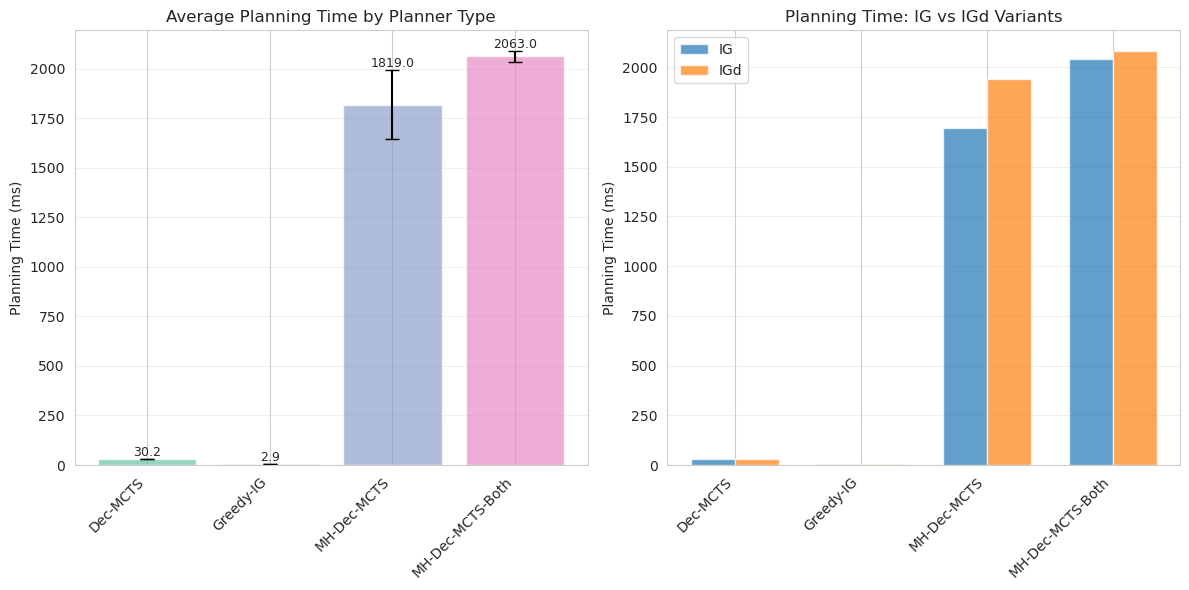

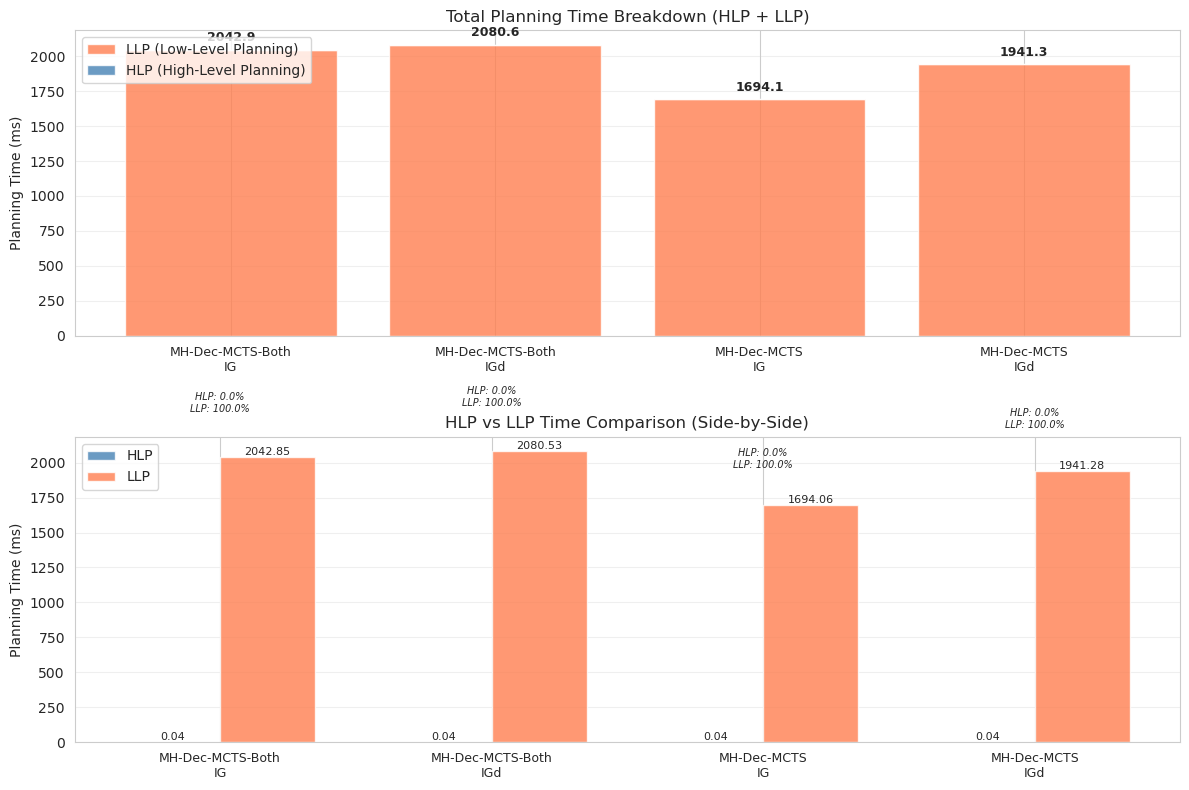


HLP/LLP Breakdown Summary:
------------------------------------------------------------
MH-Dec-MCTS-Both (IG):
  HLP: 0.04 ms (0.0%)
  LLP: 2042.85 ms (100.0%)
  Total: 2042.89 ms

MH-Dec-MCTS-Both (IGd):
  HLP: 0.04 ms (0.0%)
  LLP: 2080.53 ms (100.0%)
  Total: 2080.57 ms

MH-Dec-MCTS (IG):
  HLP: 0.04 ms (0.0%)
  LLP: 1694.06 ms (100.0%)
  Total: 1694.10 ms

MH-Dec-MCTS (IGd):
  HLP: 0.04 ms (0.0%)
  LLP: 1941.28 ms (100.0%)
  Total: 1941.32 ms



/tmp/ipykernel_40302/3556026519.py:191: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax1.boxplot(planner_data, labels=planner_labels, patch_artist=True)


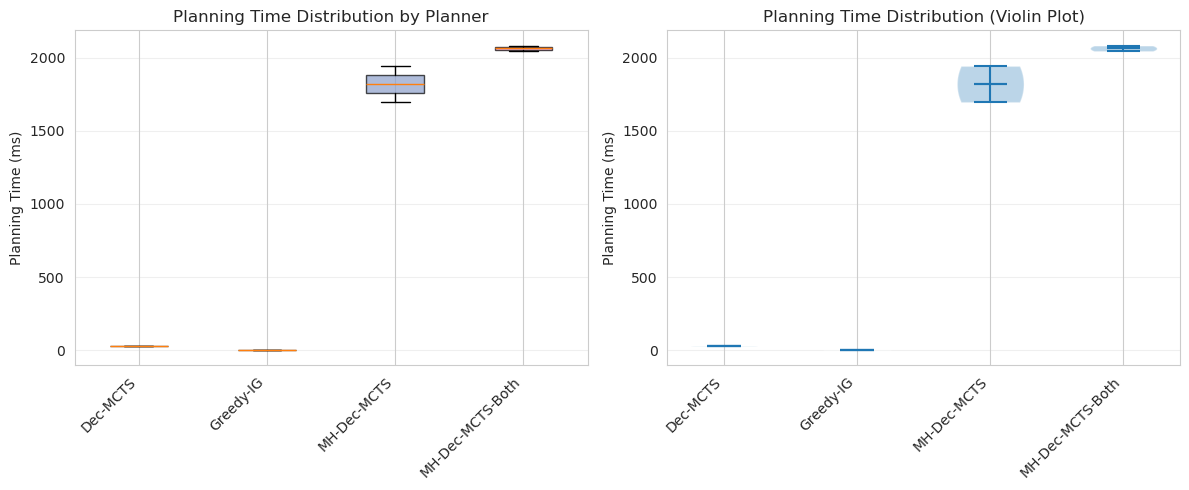

In [9]:
# Create comparison plots
plot_planning_time_comparison(df)

# Plot HLP/LLP breakdown for hierarchical planners
plot_hlp_llp_breakdown(df)

# Plot time distributions
plot_time_distribution(df)